# 09 — CIFAR-100: Transfer Learning with Vision Transformer

In notebook 07 we built a CNN from scratch and hit **~75% accuracy** on CIFAR-100. Now we're going to try something fundamentally different: instead of building a model from scratch, we'll take a **Vision Transformer (ViT)** that was already trained on 1.28 million images and adapt it for our task.

**Why we're doing this:**
Earlier we established that ViT from scratch on 50,000 images performs *worse* than a simple CNN — ViT has no built-in knowledge that nearby pixels are related, so it needs far more data to learn from zero. But a ViT that was pre-trained on ImageNet already understands edges, shapes, textures, and object parts. We're borrowing all of that knowledge.

This technique is called **transfer learning** — the model transfers knowledge from one task (ImageNet classification) to a new one (CIFAR-100).

**What you'll learn:**
- What pretrained weights are and why they're powerful
- How to modify a pretrained model for a new task (replacing the "head")
- What freezing layers means and why you do it
- How to fine-tune in two phases for best results

**Goal:** Beat our scratch CNN's best accuracy using the pretrained ViT.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random
from pathlib import Path

# Device detection — works on Windows (CUDA), Mac (MPS/CPU), and Linux
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f'Random seed set to {SEED}')

Using device: cuda
Random seed set to 42


## Step 1: Load the Data

CIFAR-100 images are 32×32 pixels, but the pretrained ViT-B/16 **requires 224×224 input**. The "16" in ViT-B/16 refers to the patch size — it divides each image into 16×16 pixel squares and treats each as a token. A 32×32 image would only produce 4 patches, which isn't enough for the model to work properly.

So we upscale every image from 32×32 → 224×224 using `transforms.Resize(224)`.

**Important — normalization must match pretraining:**
The ViT was pretrained with ImageNet normalization stats, not CIFAR-100 stats. Using the wrong normalization is like feeding the model data it doesn't recognize — accuracy drops significantly. We switch from CIFAR-100 stats to ImageNet stats here.

| | Mean | Std |
|---|---|---|
| CIFAR-100 (notebook 07) | (0.507, 0.487, 0.441) | (0.267, 0.256, 0.276) |
| ImageNet (this notebook) | (0.485, 0.456, 0.406) | (0.229, 0.224, 0.225) |

In [2]:
data_dir = Path.home() / "LocalAI" / "data"

# ImageNet normalization — must match what the ViT was pretrained with
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Training: resize to 224x224 + augmentation + ImageNet normalization
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Test: resize + normalize only (no randomness)
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

train_dataset = datasets.CIFAR100(
    root=data_dir / "cifar100", train=True,  download=True, transform=train_transform
)
test_dataset = datasets.CIFAR100(
    root=data_dir / "cifar100", train=False, download=True, transform=test_transform
)

# pin_memory only helps on CUDA — disabled automatically on Mac (MPS) and CPU
pin_memory = torch.cuda.is_available()

# Batch size 64 — 224x224 images are much larger than 32x32, so we use a smaller batch
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=pin_memory)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=pin_memory)

print(f"Data directory: {data_dir}")
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")
print(f"Image shape after transform: {train_dataset[0][0].shape}  ← should be [3, 224, 224]")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"pin_memory: {pin_memory}")

C:\Users\zacha\miniconda3\envs\localai\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Data directory: C:\Users\zacha\LocalAI\data
Training samples: 50000
Test samples:     10000
Image shape after transform: torch.Size([3, 224, 224])  ← should be [3, 224, 224]
Number of classes: 100
pin_memory: True


## Step 2: Visualize Some Samples

The images are the same CIFAR-100 data as before — just upscaled. At 224×224 they look blurrier than a native high-res photo would, but the ViT backbone can still extract meaningful features from them.

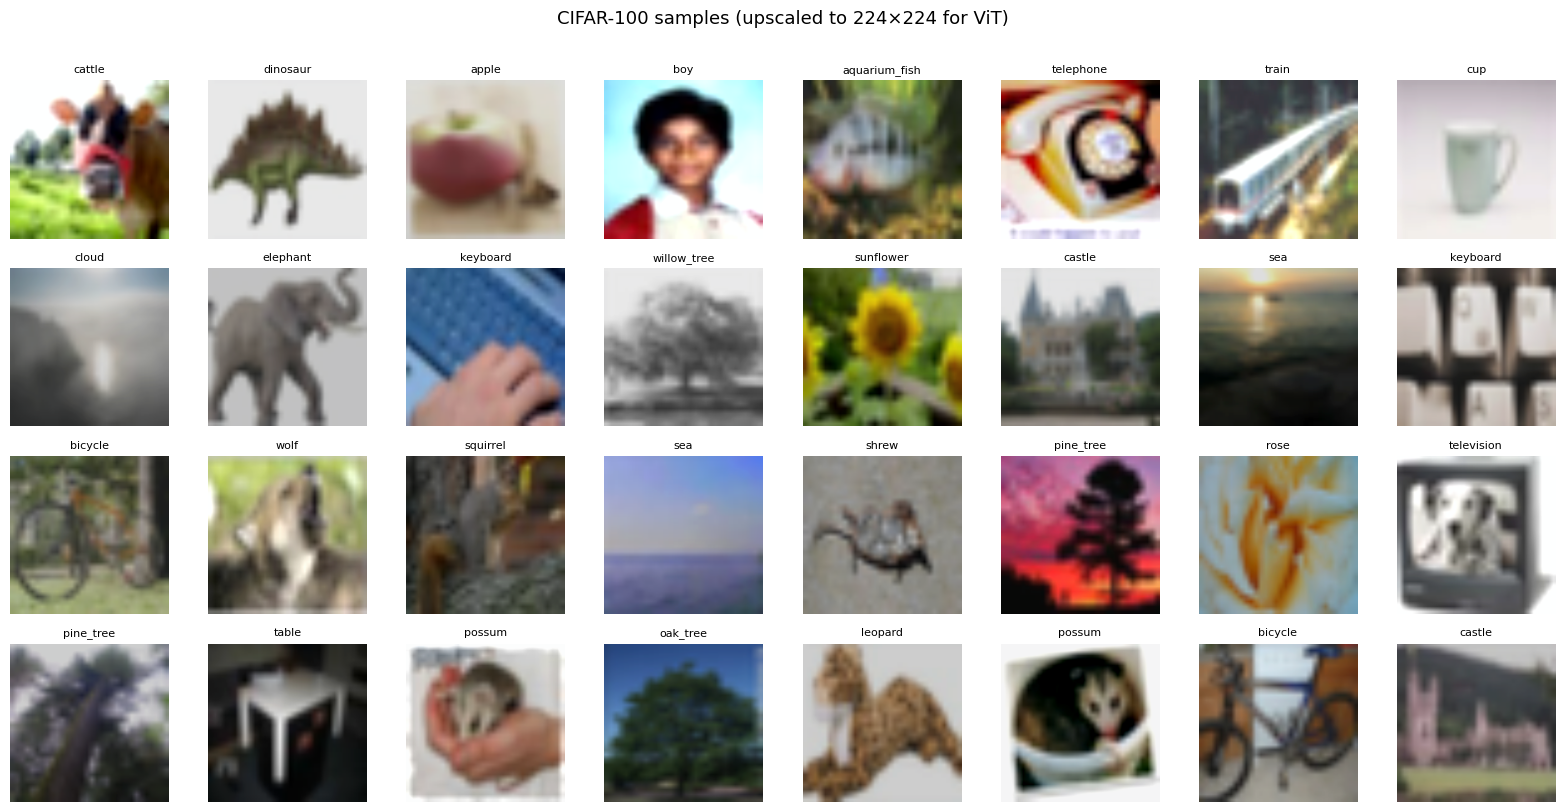

In [3]:
classes = train_dataset.classes

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    img = image.numpy().transpose(1, 2, 0)
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f'{classes[label]}', fontsize=8)
    ax.axis('off')
plt.suptitle('CIFAR-100 samples (upscaled to 224×224 for ViT)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## Step 3: Load the Pretrained ViT

**What pretrained weights are:**
Training ViT-B/16 on ImageNet-1k from scratch took weeks on dozens of GPUs. The result is a model whose 86 million parameters encode deep knowledge about visual patterns — what makes an edge, a texture, a shape, an object. When we download `ViT_B_16_Weights.DEFAULT`, we're getting all of that for free.

**What ImageNet-1k is:**
A benchmark dataset of 1.28 million images across 1,000 classes — dogs, cats, cars, household objects, animals, and more. It's broad enough that models trained on it learn general-purpose visual features that transfer well to new tasks.

**Parameter count comparison:**
| Model | Parameters | Trained on |
|---|---|---|
| Our scratch CNN (notebook 07) | ~9.7M | CIFAR-100 (50k images) |
| ViT-B/16 (this notebook) | ~86M | ImageNet-1k (1.28M images) |

The ViT has 9× more parameters *and* was trained on 25× more data. That head start is why transfer learning works.

In [4]:
# Download and load the pretrained ViT-B/16 (~330MB, downloads once)
weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights=weights)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model:          ViT-B/16')
print(f'Pretrained on:  ImageNet-1k (1.28M images, 1000 classes)')
print(f'Input size:     224×224')
print(f'Parameters:     {total_params:,}')
print()
print(f'Current output: {model.heads.head.out_features} classes (ImageNet)')
print(f'We need:        100 classes (CIFAR-100)')
print()
print('Next step: replace the output layer for CIFAR-100.')

Model:          ViT-B/16
Pretrained on:  ImageNet-1k (1.28M images, 1000 classes)
Input size:     224×224
Parameters:     86,567,656

Current output: 1000 classes (ImageNet)
We need:        100 classes (CIFAR-100)

Next step: replace the output layer for CIFAR-100.


## Step 4: Modify the Model for CIFAR-100

The pretrained ViT outputs 1000 class scores (one per ImageNet class). We need 100. To fix this, we replace the final **classification head** — the last linear layer — with a new one that outputs 100 scores instead.

Think of the model in two parts:

```
Image → [  Backbone (feature extractor)  ] → [Head] → Predictions
          (keeps all pretrained knowledge)    (we replace this)
```

- **Backbone** — the transformer blocks that extract features from the image. This is the valuable pretrained part. We keep it exactly as-is.
- **Head** — a single linear layer that maps features to class scores. This is task-specific. We swap it for one that outputs 100 scores.

The backbone outputs a 768-dimensional feature vector (the "hidden dimension" of ViT-B). Our new head maps 768 → 100.

In [5]:
# Find the existing head's input size (768 for ViT-B)
in_features = model.heads.head.in_features
print(f'Backbone output size: {in_features}')
print(f'Old head: nn.Linear({in_features}, {model.heads.head.out_features})  ← ImageNet')

# Replace with a new head for CIFAR-100
model.heads.head = nn.Linear(in_features, 100)
model = model.to(device)

print(f'New head: nn.Linear({in_features}, 100)  ← CIFAR-100')
print()

# Sanity check: verify the model outputs 100 scores for a dummy input
dummy = torch.randn(1, 3, 224, 224).to(device)
with torch.no_grad():
    out = model(dummy)
print(f'Output shape: {out.shape}  ← should be [1, 100]')

Backbone output size: 768
Old head: nn.Linear(768, 1000)  ← ImageNet
New head: nn.Linear(768, 100)  ← CIFAR-100

Output shape: torch.Size([1, 100])  ← should be [1, 100]


## Step 5: Set Up Checkpointing

Same checkpointing pattern as notebook 07, with one improvement: we now save the full training history (`train_losses` and `test_accuracies`) inside the checkpoint. This means if you reload a checkpoint later, you can still plot the full training curves — not just the final values.

In [6]:
checkpoint_dir = Path.home() / "LocalAI" / "models" / "cifar100_vit"
checkpoint_dir.mkdir(parents=True, exist_ok=True)


def save_checkpoint(epoch, model, optimizer, loss, accuracy, train_losses, test_accuracies, filename=None):
    """Save model checkpoint with full training state and history."""
    if filename is None:
        filename = f"vit_epoch_{epoch+1:02d}_{accuracy:.2%}.pt"
    checkpoint_path = checkpoint_dir / filename
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict() if optimizer else None,
        'loss': loss,
        'accuracy': accuracy,
        'train_losses': train_losses,
        'test_accuracies': test_accuracies,
    }, checkpoint_path)
    print(f"Checkpoint saved: {checkpoint_path}")


def load_checkpoint(model, optimizer=None, checkpoint_path=None):
    """Load model from checkpoint. Returns the full checkpoint dict."""
    if checkpoint_path is None:
        checkpoints = sorted(checkpoint_dir.glob("vit_epoch_*.pt"), key=lambda p: p.stat().st_mtime)
        if not checkpoints:
            print("No checkpoints found.")
            return None
        checkpoint_path = checkpoints[-1]

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer is not None and checkpoint.get('optimizer_state_dict') is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    print(f"Loaded checkpoint from epoch {checkpoint['epoch'] + 1}")
    print(f"  Loss: {checkpoint['loss']:.4f}, Accuracy: {checkpoint['accuracy']:.2%}")
    return checkpoint


print(f"Checkpoints will be stored in: {checkpoint_dir}")

Checkpoints will be stored in: C:\Users\zacha\LocalAI\models\cifar100_vit


In [7]:
# If you already trained once, load that checkpoint instead of re-training:
# checkpoint = load_checkpoint(model)
# if checkpoint:
#     train_losses     = checkpoint['train_losses']
#     test_accuracies  = checkpoint['test_accuracies']
#     phase2_start     = 5  # Phase 1 ran for 5 epochs

> **💡 Restarting the notebook?**
> Run the commented-out cell above to load your saved checkpoint, then skip Steps 6 and 7 and jump straight to Step 8 (plotting).

## Step 6: Phase 1 — Train the Head Only

We train in two phases. Phase 1 is quick: **freeze the backbone and only train the new head**.

**What freezing means:**
Every parameter in PyTorch has a `requires_grad` flag. When it's `True`, PyTorch tracks gradients for that parameter and the optimizer can update it. When it's `False`, the parameter is frozen — it never changes.

```python
param.requires_grad = False  # frozen — optimizer skips this
param.requires_grad = True   # trainable — optimizer updates this
```

**Why freeze first:**
Our new head starts with random weights. If we immediately train all 86M parameters at once, the random head produces garbage gradients that get backpropagated into the pretrained backbone — potentially corrupting the knowledge it already has. By freezing the backbone first, we let the head settle into reasonable weights before touching anything else.

Phase 1 only trains **768 × 100 + 100 = 76,900 parameters** (the head) instead of 86M — so it's very fast.

In [8]:
# --- Freeze everything, then unfreeze just the head ---
for param in model.parameters():
    param.requires_grad = False
for param in model.heads.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model.parameters())
print(f'Phase 1 — Trainable: {trainable:,} / {total_p:,} parameters ({trainable/total_p:.2%} of model)')

criterion    = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_p1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
scheduler_p1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p1, T_max=5)

n_epochs_p1     = 5
train_losses    = []
test_accuracies = []

print()
for epoch in range(n_epochs_p1):
    # --- Training ---
    model.train()
    epoch_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_p1.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_p1.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # --- Evaluation ---
    model.eval()
    correct = total_samples = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    accuracy = correct / total_samples
    test_accuracies.append(accuracy)

    current_lr = scheduler_p1.get_last_lr()[0]
    scheduler_p1.step()
    print(f'[Phase 1] Epoch {epoch+1:2d}/{n_epochs_p1}  Loss: {avg_loss:.4f}  Test Acc: {accuracy:.2%}  LR: {current_lr:.2e}')

print(f'\nPhase 1 complete. Best accuracy so far: {max(test_accuracies):.2%}')

Phase 1 — Trainable: 76,900 / 85,875,556 parameters (0.09% of model)

[Phase 1] Epoch  1/5  Loss: 1.6932  Test Acc: 79.53%  LR: 1.00e-03
[Phase 1] Epoch  2/5  Loss: 1.3803  Test Acc: 80.98%  LR: 9.05e-04
[Phase 1] Epoch  3/5  Loss: 1.3049  Test Acc: 81.34%  LR: 6.55e-04
[Phase 1] Epoch  4/5  Loss: 1.2567  Test Acc: 81.88%  LR: 3.45e-04
[Phase 1] Epoch  5/5  Loss: 1.2281  Test Acc: 81.98%  LR: 9.55e-05

Phase 1 complete. Best accuracy so far: 81.98%


## Step 7: Phase 2 — Fine-Tune the Full Model

Now we unfreeze everything and train all 86M parameters together — but with a **much lower learning rate**.

**Why such a low LR (1e-4 vs 0.001)?**
The backbone's pretrained weights already encode ImageNet knowledge. A large learning rate would overwrite that with CIFAR-100 gradients too aggressively — a phenomenon called **catastrophic forgetting**, where the model loses its prior knowledge. A small LR nudges the backbone gently toward CIFAR-100 without destroying what it already knows.

Phase 1 warmed up the head. Now both the head and backbone will adapt together, with the backbone making small, careful adjustments while the head continues to refine.

This phase is slower (all 86M parameters update each batch) but should push accuracy significantly higher than Phase 1 alone.

In [ ]:
# --- Unfreeze all layers ---
for param in model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 2 — Trainable: {trainable:,} parameters (full model)')

# Record where Phase 2 starts in the history (used for plotting the boundary line)
phase2_start = len(train_losses)

optimizer_p2 = optim.Adam(model.parameters(), lr=1e-4)
scheduler_p2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=25)

n_epochs_p2 = 25

print()
for epoch in range(n_epochs_p2):
    # --- Training ---
    model.train()
    epoch_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_p2.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_p2.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # --- Evaluation ---
    model.eval()
    correct = total_samples = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

    accuracy = correct / total_samples
    test_accuracies.append(accuracy)

    current_lr = scheduler_p2.get_last_lr()[0]
    scheduler_p2.step()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'[Phase 2] Epoch {epoch+1:2d}/{n_epochs_p2}  Loss: {avg_loss:.4f}  Test Acc: {accuracy:.2%}  LR: {current_lr:.2e}')

print(f'\nFinal test accuracy: {test_accuracies[-1]:.2%}')
print('Training complete!')

save_checkpoint(
    epoch=n_epochs_p1 + n_epochs_p2 - 1,
    model=model, optimizer=optimizer_p2,
    loss=avg_loss, accuracy=accuracy,
    train_losses=train_losses, test_accuracies=test_accuracies
)

Phase 2 — Trainable: 85,875,556 parameters (full model)



## Step 8: Plot Training Curves

These curves cover all 30 epochs across both phases. The orange dashed line marks where Phase 2 begins — you should see accuracy jump noticeably after that point as the backbone starts adapting.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(train_losses) + 1)

# Loss curve
axes[0].plot(epochs, train_losses, linewidth=2, color='steelblue')
axes[0].axvline(x=phase2_start + 0.5, color='orange', linestyle='--', alpha=0.8, label='Phase 2 starts (unfreeze all)')
axes[0].set_title('Training Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Accuracy curve
axes[1].plot(epochs, test_accuracies, linewidth=2, color='seagreen')
axes[1].axvline(x=phase2_start + 0.5, color='orange', linestyle='--', alpha=0.8, label='Phase 2 starts (unfreeze all)')
axes[1].axhline(y=0.7514, color='gray', linestyle=':', alpha=0.7, label='Scratch CNN best (75.14%)')
axes[1].set_title('Test Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Phase 1 peak (head only): {max(test_accuracies[:phase2_start]):.2%}')
print(f'Final accuracy (30 epochs): {test_accuracies[-1]:.2%}')

## Step 9: Per-Class Performance

Same analysis as notebook 07 — which classes does the ViT handle well, and where does it still struggle? Compare these to the CNN's weak spots (lobster, otter, dolphin, beaver were the worst in the CNN run).

In [ ]:
model.eval()
class_correct = [0] * 100
class_total   = [0] * 100

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += (predicted[i] == labels[i]).item()
            class_total[label] += 1

class_accuracies = [class_correct[i] / max(class_total[i], 1) for i in range(100)]
class_accuracy_pairs = sorted(zip(classes, class_accuracies), key=lambda x: x[1], reverse=True)

print('=== Top 10 Best Classified Classes ===')
for name, acc in class_accuracy_pairs[:10]:
    print(f'  {name:<25} {acc:.1%}')

print()
print('=== Top 10 Worst Classified Classes ===')
for name, acc in class_accuracy_pairs[-10:]:
    print(f'  {name:<25} {acc:.1%}')

## Step 10: ViT vs CNN — Head-to-Head Comparison

Let's compare the final accuracy of both approaches on the same test set.

The key takeaway here isn't just the number — it's *why* the ViT can do better with the same 50,000 training images. The CNN had to learn everything about visual structure from those 50k examples. The ViT arrived already knowing what edges, textures, and shapes look like from 1.28M ImageNet images. CIFAR-100 training only had to teach it *which* combinations of those features correspond to which of the 100 classes.

In [ ]:
# Best result from notebook 07 (MiniResNet trained from scratch)
# Update this value if you run notebook 07 again and get a higher accuracy
cnn_accuracy = 0.7514  # 75.14% from cifar100_epoch_60_75.14%.pt
vit_accuracy = test_accuracies[-1]

model_names = ['MiniResNet\n(from scratch)', 'ViT-B/16\n(pretrained)']
accuracies   = [cnn_accuracy, vit_accuracy]
colors       = ['steelblue', 'seagreen']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(model_names, [a * 100 for a in accuracies], color=colors, width=0.4)

for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{acc:.2%}', ha='center', va='bottom', fontsize=13, fontweight='bold'
    )

ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('CIFAR-100: Scratch CNN vs Pretrained ViT', fontsize=14)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

diff = (vit_accuracy - cnn_accuracy) * 100
direction = 'better' if diff > 0 else 'worse'
print(f'ViT is {abs(diff):.1f} percentage points {direction} than the scratch CNN.')

## Step 11: Look at Predictions

Green = correct, red = wrong. With a stronger model, you should see more green — and the mistakes should be more understandable (confusing visually similar classes rather than completely wrong predictions).

In [ ]:
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    img = images[i].cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    pred_name = classes[predicted[i].item()]
    true_name = classes[labels[i].item()]
    color = 'green' if predicted[i] == labels[i] else 'red'
    ax.set_title(f'Pred: {pred_name}\nTrue: {true_name}', fontsize=7, color=color)
    ax.axis('off')

plt.suptitle('Green = correct, Red = wrong', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## What You Built

A transfer learning pipeline that fine-tunes a pretrained Vision Transformer on CIFAR-100:

1. **Loaded CIFAR-100** with 224×224 resizing and ImageNet normalization to match ViT's pretraining
2. **Downloaded ViT-B/16** with pretrained ImageNet weights (~86M parameters)
3. **Replaced the head** — swapped the 1000-class output for a 100-class one
4. **Phase 1 training** — froze the backbone, trained the head only to initialize it properly
5. **Phase 2 fine-tuning** — unfroze everything, used a very low LR to gently adapt the backbone
6. **Compared ViT vs CNN** — saw how pretrained knowledge gives a meaningful accuracy advantage

## Things to Try

1. **More Phase 2 epochs** — accuracy may still be climbing at epoch 25; try 50 epochs
2. **Stronger augmentation** — add `transforms.RandomRotation(15)` or `transforms.AutoAugment()` to the training transform
3. **Larger ViT** — swap `vit_b_16` for `vit_l_16` (large) — more parameters, likely better accuracy
4. **Layer-wise LR decay** — use a lower LR for early backbone layers and higher for later layers (they need to change more)
5. **Try a different dataset** — use the same pipeline on CIFAR-10 or a custom image folder with `datasets.ImageFolder`
6. **Compare Phase 1-only vs two-phase** — train a second model that skips Phase 1 and goes straight to full fine-tuning; see if Phase 1 actually helps

---
## The Big Picture: When to Use Transfer Learning

| Situation | Approach |
|---|---|
| Small dataset (<100k), similar domain | Transfer learning — freeze backbone, train head |
| Medium dataset, similar domain | Transfer learning — two-phase fine-tuning (this notebook) |
| Large dataset (>1M), any domain | Train from scratch OR fine-tune |
| Very different domain (e.g. medical scans) | Fine-tune carefully — ImageNet features may not transfer as well |

In industry, training from scratch is rare. Almost every real project starts with a pretrained model.